# Marketing Performance Dashboard

## Project Overview

The goal of this project is to analyze digital marketing campaign performance and turn raw data into meaningful business insights.

Using Python, SQL, Power BI, and Streamlit, we will clean the data, calculate marketing KPIs, explore campaign performance, and build an interactive dashboard that helps evaluate marketing effectiveness across different platforms, campaigns, and time periods.

This project follows the workflow recommended in the capstone project:
- Data Inspection
- Data Cleaning
- Feature Engineering (if required)
- Exploratory Data Analysis (EDA)
- KPI Analysis
- SQL Analysis
- Power BI Dashboard
- Streamlit Deployment

In [2]:
# ==================================================
# Import Required Libraries
# ==================================================

# Data Manipulation
import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.max_columns", None)   # Show all columns
pd.set_option("display.max_rows", 100)       # Show up to 100 rows
pd.set_option("display.width", None)         # Prevent line wrapping
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt

# Ignore Warning Messages
import warnings
warnings.filterwarnings("ignore")

# 2. Load the Dataset

## Objective

The purpose of this step is to load the raw dataset into Python and verify that it has been imported correctly.

Before starting data cleaning or analysis, it is important to make sure the dataset loads without errors and that the columns and sample records look as expected. This helps confirm that we are working with the correct data.

In [3]:
# Load the dataset
df = pd.read_csv("/content/digital_marketing_dataset_30k.csv")

# Display the first 10 rows
df.head(10)

,date,year,month,month_name,week,day_of_week,post_hour,season,is_holiday,is_holiday (text),is_weekend,is_weekend (text),country,market_tier,account,account_type,platform,placement,funnel_stage,objective,theme,campaign_id,campaign_name,ad_group_id,ad_group_name,ad_id,ad_name,spend,impressions,reach,frequency,clicks,conversions,revenue,video_views
0,08/04/2023,2023,4,Apr,14,Sat,7,Spring,0,No,1,Yes,Iraq,Tier 1,Travel_SkyTrip,Brand,TikTok,In-Feed,Awareness,Reach,Product Launch,C30853,Travel_SkyTrip_Product Launch_Awareness_TikTok...,AG412799,Product Launch_In-Feed_6,AD8747890,In-Feed_V1,871.17,172632,77865,2.22,1440,0,0.00,54610
1,28/04/2025,2025,4,Apr,18,Mon,12,Spring,0,No,0,No,Morocco,Tier 1,FMCG_Foodies,Brand,Meta,Feed,Awareness,Video Views,Seasonal,C49194,FMCG_Foodies_Seasonal_Awareness_Meta_Apr_2025,AG863446,Seasonal_Feed_42,AD2884130,Feed_V9,362.55,30111,15083,2.00,283,0,0.00,8086
2,18/12/2024,2024,12,Dec,51,Wed,10,Winter,0,No,0,No,United Arab Emirates,Tier 1,Ecom_FashionCo,Brand,Google Display,Display,Conversion,Sales,UGC,C54438,Ecom_FashionCo_UGC_Conversion_Google Display_D...,AG769411,UGC_Display_2,AD5656772,Display_V7,362.09,111125,56453,1.97,1238,7,671.74,0
3,26/04/2024,2024,4,Apr,17,Fri,20,Spring,0,No,0,No,KSA,Tier 1,Ecom_ElectroHub,Brand,Snapchat,Stories,Consideration,Traffic,Educational,C60684,Ecom_ElectroHub_Educational_Consideration_Snap...,AG131656,Educational_Stories_49,AD3443678,Stories_V2,54.45,10844,4736,2.29,83,0,0.00,0
4,19/04/2024,2024,4,Apr,16,Fri,22,Spring,0,No,0,No,Bahrain,Tier 3,FMCG_Foodies,Brand,Meta,Reels,Awareness,Reach,Retargeting,C57210,FMCG_Foodies_Retargeting_Awareness_Meta_Apr_2024,AG633873,Retargeting_Reels_37,AD8461978,Reels_V8,56.18,6423,3010,2.13,59,0,0.00,1160
5,30/07/2025,2025,7,Jul,31,Wed,18,Summer,0,No,0,No,Bahrain,Tier 3,Education_Academy,Brand,Meta,Stories,Conversion,Sales,Influencer,C37074,Education_Academy_Influencer_Conversion_Meta_J...,AG623399,Influencer_Stories_6,AD7498590,Stories_V3,53.98,10535,3910,2.69,132,2,82.52,0
6,05/04/2023,2023,4,Apr,14,Wed,1,Spring,0,No,0,No,KSA,Tier 1,Travel_SkyTrip,Creator,LinkedIn,Feed,Consideration,Engagement,Product Launch,C56930,Travel_SkyTrip_Product Launch_Consideration_Li...,AG198420,Product Launch_Feed_10,AD8234714,Feed_V6,1242.00,39560,20952,1.89,278,0,0.00,0
7,03/02/2025,2025,2,Feb,6,Mon,23,Winter,0,No,0,No,United Arab Emirates,Tier 1,B2B_SaaSCloud,Brand,TikTok,In-Feed,Consideration,Traffic,Product Launch,C71277,B2B_SaaSCloud_Product Launch_Consideration_Tik...,AG248924,Product Launch_In-Feed_26,AD9894159,In-Feed_V5,129.16,25800,10446,2.47,199,0,0.00,5819
8,09/08/2023,2023,8,Aug,32,Wed,6,Summer,0,No,0,No,Iraq,Tier 1,Ecom_FashionCo,Brand,Meta,Feed,Awareness,Reach,Retargeting,C25272,Ecom_FashionCo_Retargeting_Awareness_Meta_Aug_...,AG211479,Retargeting_Feed_24,AD6898000,Feed_V3,935.07,167666,70297,2.39,1207,0,0.00,0
9,14/04/2023,2023,4,Apr,15,Fri,12,Spring,0,No,0,No,Jordan,Tier 3,Ecom_ElectroHub,Brand,TikTok,In-Feed,Conversion,Sales,Educational,C19255,Ecom_ElectroHub_Educational_Conversion_TikTok_...,AG443390,Educational_In-Feed_18,AD5276406,In-Feed_V1,1033.53,250077,84723,2.95,2919,30,1348.30,41946


# 3. Data Inspection

## Objective

Before cleaning or analyzing the dataset, it is important to understand its overall structure and quality.

In this section, we will examine the size of the dataset, review the data types of each column, identify missing values and duplicate records, and generate summary statistics for numerical variables.

This helps us detect potential data quality issues and decide what needs to be cleaned before moving on to analysis.

In [4]:
# Dataset Shape
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 30000
Number of Columns : 35


In [5]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 35 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               30000 non-null  object 
 1   year               30000 non-null  int64  
 2   month              30000 non-null  int64  
 3   month_name         30000 non-null  object 
 4   week               30000 non-null  int64  
 5   day_of_week        30000 non-null  object 
 6   post_hour          30000 non-null  int64  
 7   season             30000 non-null  object 
 8   is_holiday         30000 non-null  int64  
 9   is_holiday (text)  30000 non-null  object 
 10  is_weekend         30000 non-null  int64  
 11  is_weekend (text)  30000 non-null  object 
 12  country            30000 non-null  object 
 13  market_tier        30000 non-null  object 
 14  account            30000 non-null  object 
 15  account_type       30000 non-null  object 
 16  platform           300

In [6]:
# Statistical Summary
df.describe()

,year,month,week,post_hour,is_holiday,is_weekend,spend,impressions,reach,frequency,clicks,conversions,revenue,video_views
count,30000.000000,30000.000000,30000.0000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,2023.995833,6.528000,26.4568,11.504133,0.015833,0.283800,421.213635,5.672545e+04,28648.652500,2.068052,853.904667,10.759933,475.711809,5176.542333
std,0.815540,3.451774,15.0875,6.916279,0.124833,0.450848,463.299038,8.022802e+04,41973.091136,0.415826,1485.987745,54.295895,2814.167209,13486.544115
min,2023.000000,1.000000,1.0000,0.000000,0.000000,0.000000,18.840000,6.930000e+02,277.000000,1.110000,3.000000,0.000000,0.000000,0.000000
25%,2023.000000,4.000000,13.0000,5.000000,0.000000,0.000000,86.147500,9.432750e+03,4652.750000,1.750000,109.000000,0.000000,0.000000,0.000000
50%,2024.000000,7.000000,27.0000,11.000000,0.000000,0.000000,229.915000,2.543800e+04,12516.000000,2.060000,311.500000,1.000000,0.000000,0.000000
75%,2025.000000,10.000000,40.0000,18.000000,0.000000,1.000000,609.312500,6.961450e+04,34562.250000,2.370000,961.000000,3.000000,72.350000,3245.250000
max,2025.000000,12.000000,52.0000,23.000000,1.000000,1.000000,3759.940000,1.015972e+06,682100.000000,3.200000,30884.000000,2701.000000,104733.410000,218753.000000


In [7]:
# Missing Values
df.isnull().sum()

,0
date,0
year,0
month,0
month_name,0
week,0
day_of_week,0
post_hour,0
season,0
is_holiday,0
is_holiday (text),0


In [8]:
# Duplicate Records
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns.tolist()

['date',
 'year',
 'month',
 'month_name',
 'week',
 'day_of_week',
 'post_hour',
 'season',
 'is_holiday',
 'is_holiday (text)',
 'is_weekend',
 'is_weekend (text)',
 'country',
 'market_tier',
 'account',
 'account_type',
 'platform',
 'placement',
 'funnel_stage',
 'objective',
 'theme',
 'campaign_id',
 'campaign_name',
 'ad_group_id',
 'ad_group_name',
 'ad_id',
 'ad_name',
 'spend',
 'impressions',
 'reach',
 'frequency',
 'clicks',
 'conversions',
 'revenue',
 'video_views']

# 4. Data Cleaning

## Objective

The purpose of data cleaning is to ensure that the dataset is accurate, consistent, and ready for analysis.

During this step, we verify data types, check for missing values and duplicate records, and make necessary corrections before performing exploratory data analysis and KPI calculations.

A clean dataset improves the accuracy and reliability of the insights generated later in the project.

In [9]:
# Convert 'date' column to datetime format

df["date"] = pd.to_datetime(
    df["date"],
    format="%d/%m/%Y"
)

# Verify the updated data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 35 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               30000 non-null  datetime64[ns]
 1   year               30000 non-null  int64         
 2   month              30000 non-null  int64         
 3   month_name         30000 non-null  object        
 4   week               30000 non-null  int64         
 5   day_of_week        30000 non-null  object        
 6   post_hour          30000 non-null  int64         
 7   season             30000 non-null  object        
 8   is_holiday         30000 non-null  int64         
 9   is_holiday (text)  30000 non-null  object        
 10  is_weekend         30000 non-null  int64         
 11  is_weekend (text)  30000 non-null  object        
 12  country            30000 non-null  object        
 13  market_tier        30000 non-null  object        
 14  accoun

In [10]:
# Check missing values
df.isnull().sum()

,0
date,0
year,0
month,0
month_name,0
week,0
day_of_week,0
post_hour,0
season,0
is_holiday,0
is_holiday (text),0


In [11]:
# Check missing values
df.duplicated().sum()

np.int64(0)

# 5. Feature Engineering

## Objective

Feature engineering is the process of creating new variables from existing data to make the dataset more useful for analysis.

In this project, we will create important marketing KPIs that are commonly used to measure campaign performance. These new features will help us perform better analysis, answer business questions, and build a more informative Power BI dashboard.

In [13]:


# Click-Through Rate (CTR)
df["CTR"] = np.where(
    df["impressions"] > 0,
    (df["clicks"] / df["impressions"]) * 100,
    0
)

# Cost Per Click (CPC)
df["CPC"] = np.where(
    df["clicks"] > 0,
    df["spend"] / df["clicks"],
    0
)

# Cost Per 1,000 Impressions (CPM)
df["CPM"] = np.where(
    df["impressions"] > 0,
    (df["spend"] / df["impressions"]) * 1000,
    0
)

# Cost Per Acquisition (CPA)
df["CPA"] = np.where(
    df["conversions"] > 0,
    df["spend"] / df["conversions"],
    0
)

# Return On Ad Spend (ROAS)
df["ROAS"] = np.where(
    df["spend"] > 0,
    df["revenue"] / df["spend"],
    0
)

In [14]:
df[["CTR", "CPC", "CPM", "CPA", "ROAS"]].head(10)

,CTR,CPC,CPM,CPA,ROAS
0,0.834144,0.604979,5.046399,0.000000,0.000000
1,0.939856,1.281095,12.040450,0.000000,0.000000
2,1.114061,0.292480,3.258403,51.727143,1.855174
3,0.765400,0.656024,5.021210,0.000000,0.000000
4,0.918574,0.952203,8.746692,0.000000,0.000000
5,1.252966,0.408939,5.123873,26.990000,1.528714
6,0.702730,4.467626,31.395349,0.000000,0.000000
7,0.771318,0.649045,5.006202,0.000000,0.000000
8,0.719884,0.774706,5.576980,0.000000,0.000000
9,1.167240,0.354070,4.132847,34.451000,1.304558


In [15]:
df[["CTR", "CPC", "CPM", "CPA", "ROAS"]].describe()

,CTR,CPC,CPM,CPA,ROAS
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,1.823630,1.276810,11.667643,129.234281,1.076159
std,2.022371,1.720689,9.276566,295.062868,3.882109
min,0.186053,0.071498,2.500471,0.000000,0.000000
25%,0.728176,0.374642,5.041380,0.000000,0.000000
50%,0.985030,0.606615,8.177510,3.914749,0.000000
75%,1.436671,1.097723,15.693819,81.732500,0.489142
max,13.759800,16.698571,45.000000,3759.940000,92.001153


# 6. Exploratory Data Analysis (EDA)

## Objective

Exploratory Data Analysis (EDA) is the process of examining and visualizing data to better understand its characteristics before performing detailed analysis.

The main objective of EDA is to identify patterns, understand the distribution of variables, detect unusual values, and generate meaningful business insights.

In this project, EDA will help evaluate marketing campaign performance and support the development of an interactive Power BI dashboard.

## 6.1 Univariate Analysis

### What is Univariate Analysis?

Univariate analysis focuses on one variable at a time. It helps us understand how a single variable is distributed without comparing it to other variables.

In this section, we will analyze the distribution of important marketing KPIs and campaign metrics to understand their overall behavior.

### Distribution of Advertising Spend

#### Objective

The objective of this analysis is to understand how advertising spend is distributed across marketing campaigns.

This visualization helps identify whether most campaigns have similar budgets or if spending varies significantly across campaigns.

In [16]:
import os

# Create folders for saving charts
os.makedirs("charts/univariate", exist_ok=True)
os.makedirs("charts/bivariate", exist_ok=True)
os.makedirs("charts/multivariate", exist_ok=True)

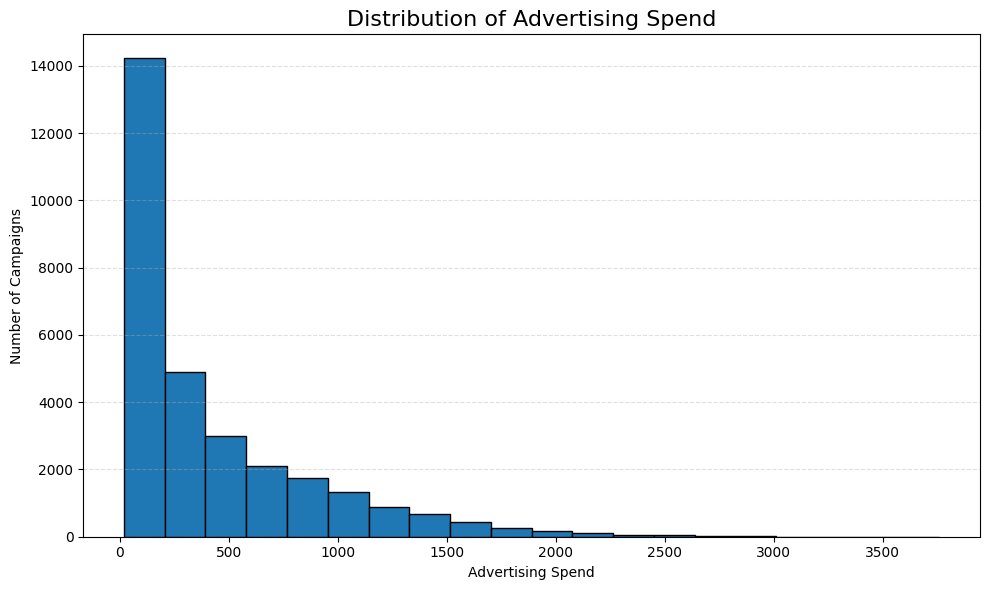

In [17]:
# Distribution of Advertising Spend

plt.figure(figsize=(10,6))

plt.hist(
    df["spend"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Advertising Spend", fontsize=16)
plt.xlabel("Advertising Spend")
plt.ylabel("Number of Campaigns")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

# Save the chart
plt.savefig(
    "charts/univariate/spend_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Interpretation

The histogram shows that advertising spend is not evenly distributed across campaigns.

Most campaigns operate with relatively low advertising budgets, while only a small number of campaigns receive significantly higher investments. This creates a right-skewed distribution, indicating that marketing resources are concentrated in a limited number of high-budget campaigns.

This insight suggests that organizations allocate larger budgets to selected campaigns while keeping the majority of campaigns within lower spending ranges.

### Distribution of Revenue

#### Objective

The objective of this analysis is to examine how revenue is distributed across marketing campaigns.

Understanding the revenue distribution helps identify whether most campaigns generate similar revenue or if only a small number of campaigns contribute significantly to the overall revenue.

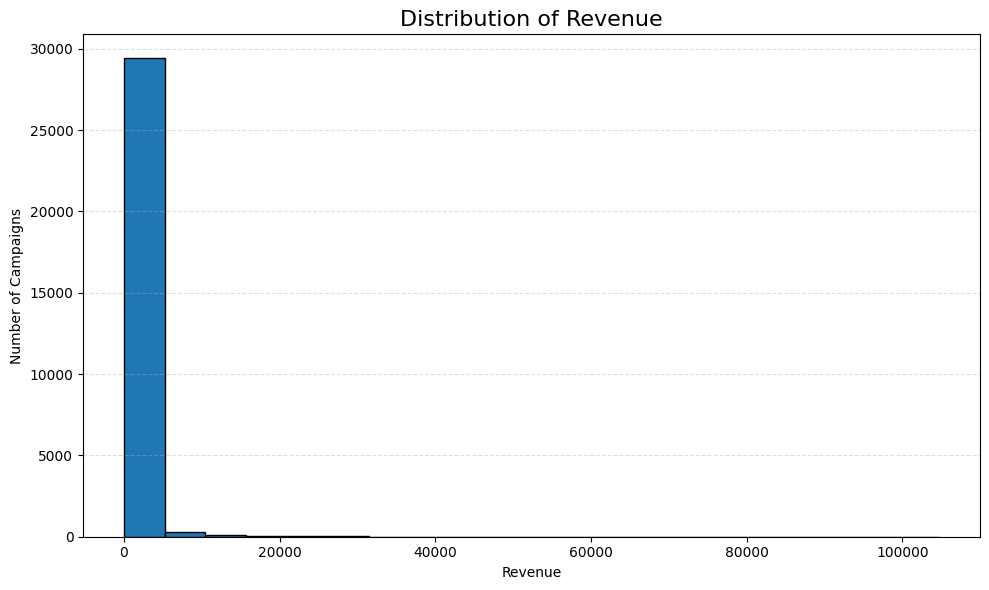

In [18]:
# Distribution of Revenue

plt.figure(figsize=(10,6))

plt.hist(
    df["revenue"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Revenue", fontsize=16)
plt.xlabel("Revenue")
plt.ylabel("Number of Campaigns")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

# Save chart
plt.savefig(
    "charts/univariate/revenue_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Interpretation

The histogram shows that revenue is highly concentrated at the lower end of the distribution, while only a small number of campaigns generate very high revenue.

The distribution is strongly positively (right) skewed, indicating that most campaigns produce little or no revenue, whereas a few high-performing campaigns contribute a disproportionately large share of the total revenue.

This pattern suggests that marketing success is uneven across campaigns, with only a limited number of campaigns delivering exceptional financial results.

### Distribution of Click-Through Rate (CTR)

#### Objective

The objective of this analysis is to examine the distribution of Click-Through Rate (CTR) across all marketing campaigns.

CTR measures the percentage of users who clicked on an advertisement after seeing it. Analyzing its distribution helps identify how effectively campaigns attract user engagement and whether campaign performance is consistent across the dataset.

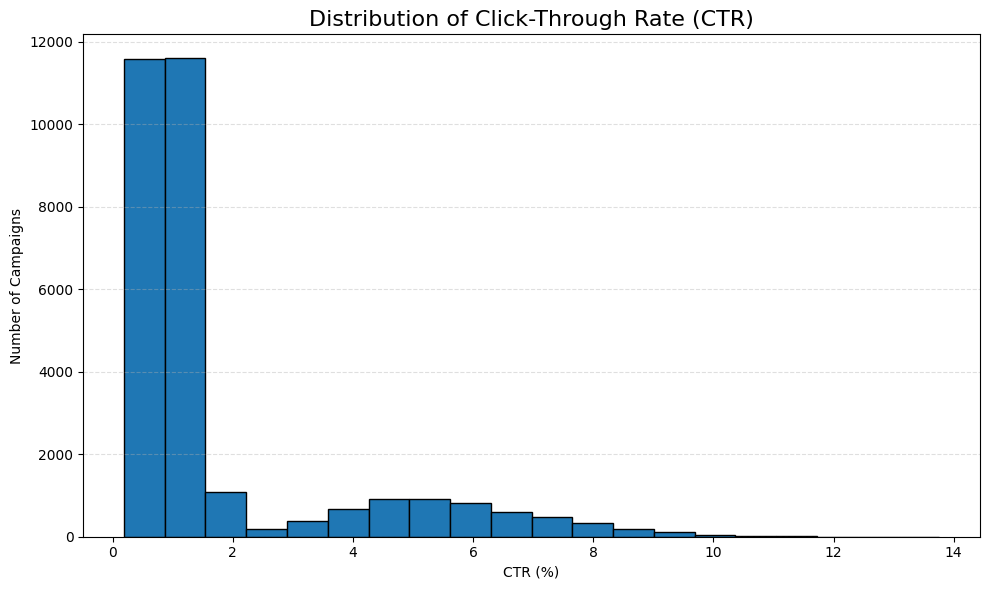

In [19]:
# Distribution of Click-Through Rate (CTR)

plt.figure(figsize=(10,6))

plt.hist(
    df["CTR"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Click-Through Rate (CTR)", fontsize=16)
plt.xlabel("CTR (%)")
plt.ylabel("Number of Campaigns")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

# Save chart
plt.savefig(
    "charts/univariate/ctr_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Interpretation

The histogram shows that most marketing campaigns have a relatively low Click-Through Rate (CTR), with the majority of campaigns clustered below 2%.

The distribution is positively (right) skewed, indicating that while most campaigns receive modest user engagement, a smaller number of campaigns achieve significantly higher CTR values.

This suggests that only a limited number of campaigns are highly effective at attracting user clicks, whereas most campaigns perform within the lower CTR range.

# 6.2 Bivariate Analysis
## Objective

The objective of this section is to compare important marketing metrics across different business dimensions such as platform, campaign objective, country, and time period.

By exploring these relationships, we can identify which factors contribute to better campaign performance and generate insights that support data-driven marketing decisions.

### Average Revenue by Platform

#### Objective

The objective of this analysis is to compare the average revenue generated by different marketing platforms.

This helps identify which platforms consistently generate higher revenue and can support decisions related to future budget allocation.

In [20]:
# Average Revenue by Platform

platform_revenue = (
    df.groupby("platform")["revenue"]
      .mean()
      .sort_values(ascending=False)
)

platform_revenue

,revenue
platform,
Google Search,1815.059585
Meta,238.838762
Snapchat,185.883100
TikTok,181.792729
Google Display,108.956952
LinkedIn,51.876838


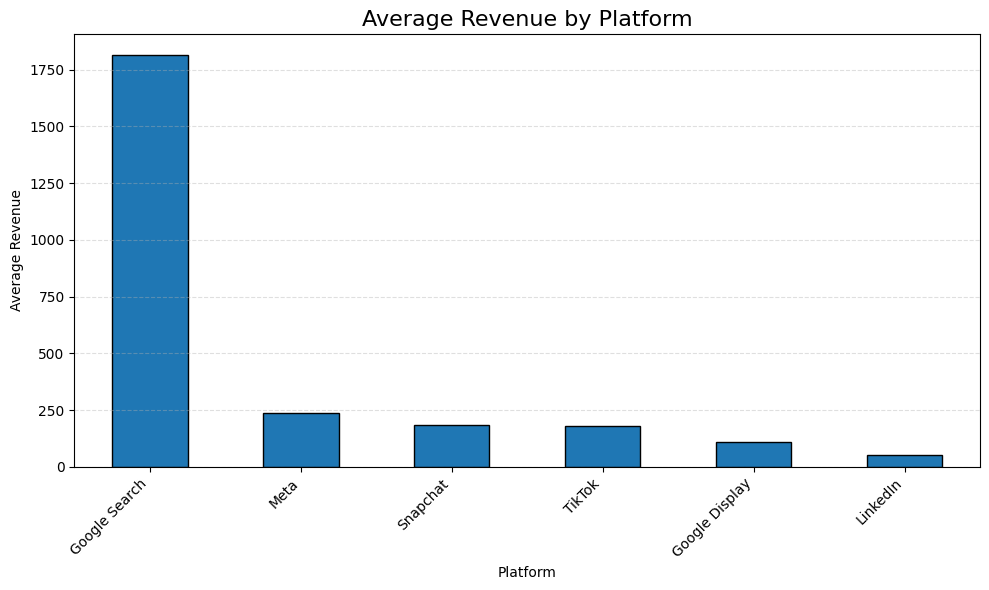

In [21]:
# Average Revenue by Platform

plt.figure(figsize=(10,6))

platform_revenue.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Average Revenue by Platform", fontsize=16)
plt.xlabel("Platform")
plt.ylabel("Average Revenue")

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

# Save chart
plt.savefig(
    "charts/bivariate/average_revenue_by_platform.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Interpretation

The chart compares the average revenue generated across different marketing platforms.

Google Search has the highest average revenue by a significant margin, outperforming all other platforms in the dataset. Meta ranks second, followed by Snapchat and TikTok, while Google Display and LinkedIn generate the lowest average revenue.

The large gap between Google Search and the remaining platforms suggests that campaigns running on Google Search are considerably more effective at generating revenue. This insight indicates that Google Search may be delivering a stronger return and could be considered a priority platform when planning future marketing investments.

### Average Advertising Spend by Platform

#### Objective

The objective of this analysis is to compare the average advertising spend across different marketing platforms.

This helps us understand how marketing budgets are distributed and whether platforms receiving higher investments are also generating higher revenue.

In [22]:
# Average Advertising Spend by Platform

platform_spend = (
    df.groupby("platform")["spend"]
      .mean()
      .sort_values(ascending=False)
)

platform_spend

,spend
platform,
Google Search,480.688597
LinkedIn,478.808889
Snapchat,402.682750
Meta,383.952605
Google Display,383.773493
TikTok,382.522705


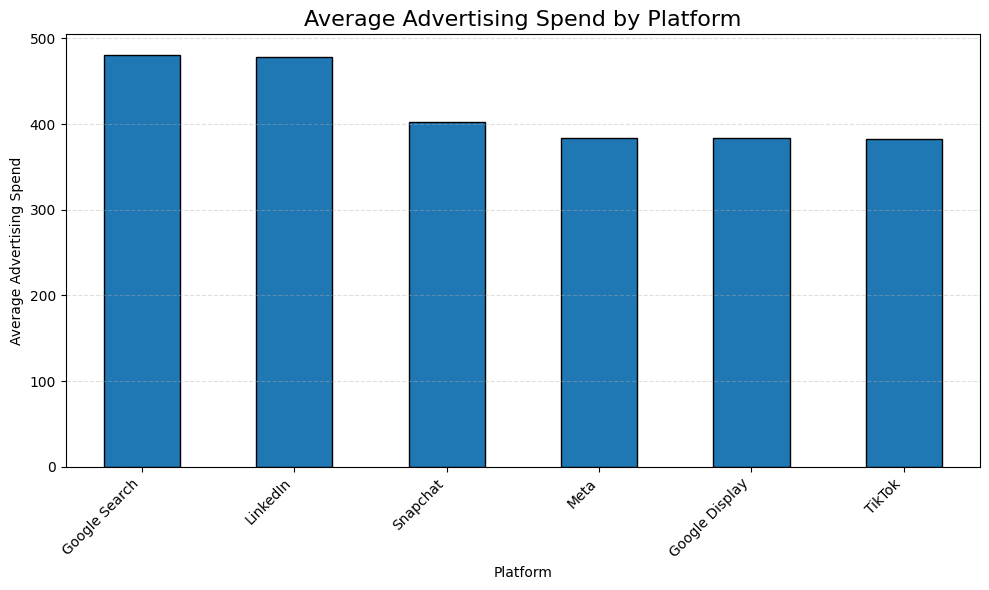

In [23]:
# Average Advertising Spend by Platform

plt.figure(figsize=(10,6))

platform_spend.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Average Advertising Spend by Platform", fontsize=16)
plt.xlabel("Platform")
plt.ylabel("Average Advertising Spend")

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

# Save chart
plt.savefig(
    "charts/bivariate/average_spend_by_platform.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Interpretation

The chart compares the average advertising spend across different marketing platforms.

Google Search has the highest average advertising spend, followed closely by LinkedIn. Snapchat ranks third, while Meta, Google Display, and TikTok have relatively similar average spending levels.

When this analysis is compared with the previous revenue analysis, an interesting pattern emerges. Although LinkedIn receives one of the highest average advertising budgets, it generates the lowest average revenue among all platforms. In contrast, Google Search not only has the highest average spend but also delivers the highest average revenue.

This suggests that higher advertising spend alone does not guarantee better performance. The effectiveness of the platform plays an equally important role in determining campaign success.

### Average Return on Ad Spend (ROAS) by Platform

#### Objective

The objective of this analysis is to compare the average Return on Ad Spend (ROAS) across different marketing platforms.

ROAS measures how much revenue is generated for every unit of advertising spend. Comparing ROAS across platforms helps identify which platforms use marketing budgets most efficiently and generate the strongest financial return.

In [24]:
# Average ROAS by Platform

platform_roas = (
    df.groupby("platform")["ROAS"]
      .mean()
      .sort_values(ascending=False)
)

platform_roas

,ROAS
platform,
Google Search,3.849727
Meta,0.648387
TikTok,0.506366
Snapchat,0.484828
Google Display,0.281490
LinkedIn,0.091847


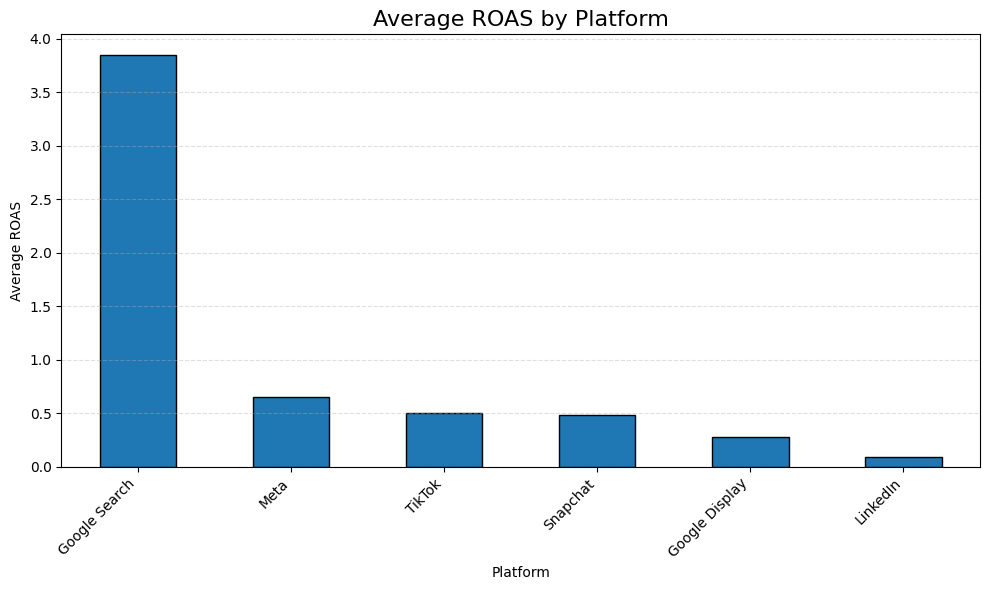

In [25]:
# Average ROAS by Platform

plt.figure(figsize=(10,6))

platform_roas.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Average ROAS by Platform", fontsize=16)
plt.xlabel("Platform")
plt.ylabel("Average ROAS")

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

# Save chart
plt.savefig(
    "charts/bivariate/average_roas_by_platform.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Interpretation

The chart compares the average Return on Ad Spend (ROAS) across different marketing platforms.

Google Search has the highest average ROAS by a substantial margin, indicating that it generates significantly more revenue for every unit of advertising spend than the other platforms. Meta ranks second, followed by TikTok and Snapchat, while Google Display and LinkedIn have the lowest ROAS values.

When this result is compared with the previous analyses, it becomes clear that Google Search not only generates the highest revenue but also delivers the strongest return on advertising investment. In contrast, LinkedIn receives one of the highest average advertising budgets but produces the lowest ROAS, suggesting that its campaigns are considerably less cost-effective.

Overall, the results indicate that platform selection has a major influence on marketing efficiency, and increasing advertising spend alone does not guarantee better financial returns.

### Average Click-Through Rate (CTR) by Platform

#### Objective

The objective of this analysis is to compare the average Click-Through Rate (CTR) across different marketing platforms.

CTR measures the percentage of users who click on an advertisement after viewing it. Comparing CTR across platforms helps identify which platforms are more successful at capturing user attention and encouraging engagement.

A higher CTR generally indicates that advertisements are more relevant and appealing to the target audience.

In [26]:
# Average CTR by Platform

platform_ctr = (
    df.groupby("platform")["CTR"]
      .mean()
      .sort_values(ascending=False)
)

platform_ctr

,CTR
platform,
Google Search,5.652914
Meta,1.186767
TikTok,0.976549
Snapchat,0.928207
Google Display,0.672200
LinkedIn,0.669992


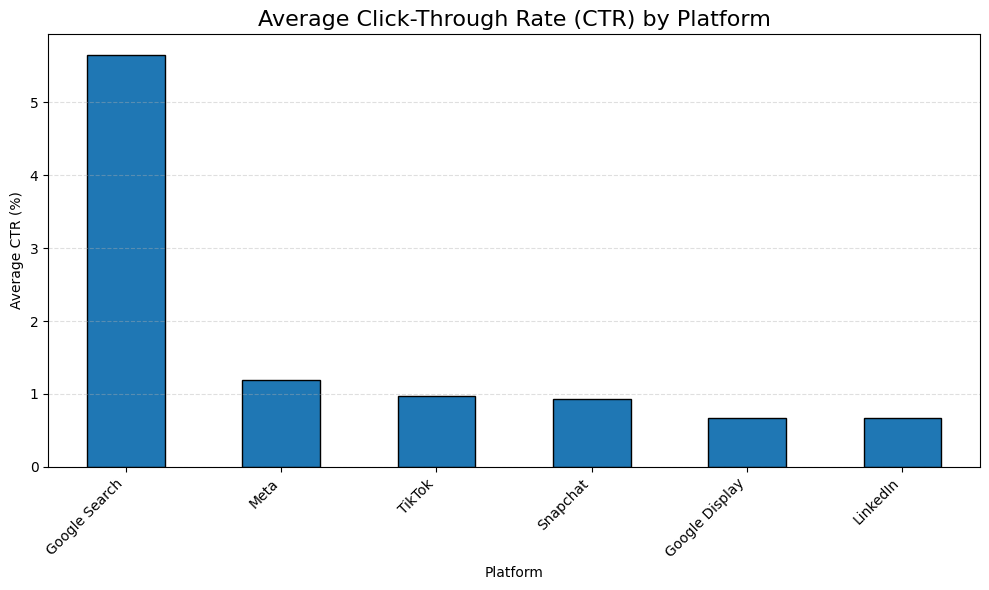

In [27]:
# Average CTR by Platform

plt.figure(figsize=(10,6))

platform_ctr.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Average Click-Through Rate (CTR) by Platform", fontsize=16)
plt.xlabel("Platform")
plt.ylabel("Average CTR (%)")

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

# Save chart
plt.savefig(
    "charts/bivariate/average_ctr_by_platform.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Interpretation

The chart compares the average Click-Through Rate (CTR) across different marketing platforms.

Google Search records the highest average CTR, indicating that users are much more likely to click on advertisements displayed on this platform than on any other platform. Meta ranks second, followed by TikTok and Snapchat, while Google Display and LinkedIn have the lowest average CTR values.

When combined with the previous analyses, Google Search consistently performs better across multiple performance indicators, including revenue, advertising efficiency, and user engagement. In contrast, LinkedIn and Google Display show relatively low CTR values, suggesting that their advertisements are less effective at attracting user attention.

Overall, the results indicate that platform choice has a significant impact on user engagement, making it an important factor when planning digital marketing campaigns.

### Average Revenue by Campaign Objective

#### Objective

The objective of this analysis is to compare the average revenue generated by different campaign objectives.

Campaigns are created with different goals, such as increasing brand awareness, driving website traffic, generating leads, or increasing conversions. Comparing the average revenue for each objective helps identify which marketing goals are associated with stronger financial performance.

In [28]:
# Average Revenue by Campaign Objective

objective_revenue = (
    df.groupby("objective")["revenue"]
      .mean()
      .sort_values(ascending=False)
)

objective_revenue

,revenue
objective,
Sales,1894.889169
Leads,877.176753
Engagement,0.000000
Reach,0.000000
Traffic,0.000000
Video Views,0.000000


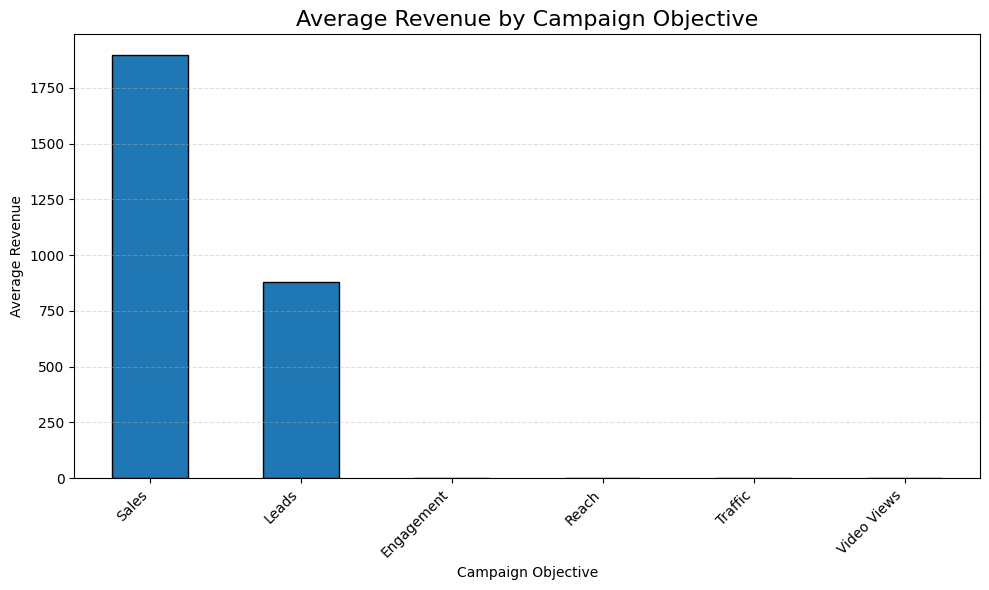

In [29]:
# Average Revenue by Campaign Objective

plt.figure(figsize=(10,6))

objective_revenue.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Average Revenue by Campaign Objective", fontsize=16)
plt.xlabel("Campaign Objective")
plt.ylabel("Average Revenue")

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

# Save chart
plt.savefig(
    "charts/bivariate/average_revenue_by_objective.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Interpretation

The chart compares the average revenue generated by different campaign objectives.

Sales campaigns generate the highest average revenue, followed by Lead Generation campaigns. In contrast, campaigns focused on Engagement, Reach, Traffic, and Video Views do not generate direct revenue in this dataset, resulting in an average revenue of zero.

This pattern suggests that the dataset reflects different campaign purposes. Objectives such as Sales and Leads are designed to produce measurable business outcomes, whereas Engagement, Reach, Traffic, and Video Views primarily focus on increasing audience interaction, visibility, or website visits rather than immediate revenue generation.

These findings highlight that campaign performance should always be evaluated based on its intended objective. Measuring awareness campaigns only by revenue would not provide a fair assessment of their effectiveness.

### Monthly Revenue Trend

#### Objective

The objective of this analysis is to examine how average revenue changes across different months.

Time-based analysis helps identify seasonal trends, periods of strong performance, and months where revenue declines. Understanding these patterns can support better campaign planning, budget allocation, and marketing strategy throughout the year.

In [30]:
# Average Revenue by Month

monthly_revenue = (
    df.groupby("month_name")["revenue"]
      .mean()
)

# Arrange months in calendar order
month_order = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

monthly_revenue = monthly_revenue.reindex(month_order)

monthly_revenue

,revenue
month_name,
Jan,373.506145
Feb,320.048288
Mar,340.091728
Apr,424.219765
May,316.018102
Jun,280.119493
Jul,303.384236
Aug,233.601193
Sep,483.677267


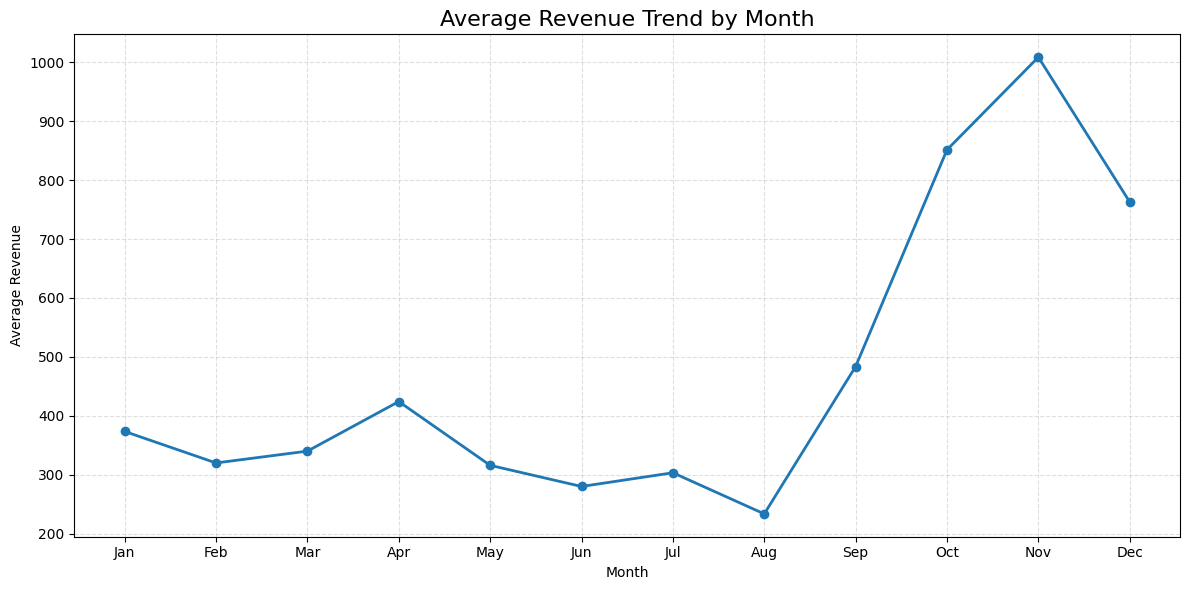

In [31]:
# Monthly Revenue Trend

plt.figure(figsize=(12,6))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o",
    linewidth=2
)

plt.title("Average Revenue Trend by Month", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Average Revenue")

plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()

# Save chart
plt.savefig(
    "charts/bivariate/monthly_revenue_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Interpretation

The line chart shows how average revenue changes throughout the year.

Revenue remains relatively stable from January to August, with only moderate month-to-month fluctuations. Beginning in September, revenue increases noticeably, followed by a sharp rise in October and November. November records the highest average revenue of the year, while December shows a slight decline but still remains significantly higher than the earlier months.

This trend suggests that marketing campaigns become substantially more effective during the final quarter of the year. The increase may reflect seasonal shopping periods, promotional campaigns, or higher customer demand during the end-of-year months.

Overall, the analysis indicates that revenue follows a seasonal pattern, with the strongest campaign performance occurring between September and December.

### Average Revenue by Country

#### Objective

The objective of this analysis is to compare the average revenue generated across different countries.

This analysis helps identify the markets that contribute the highest revenue and highlights geographical differences in campaign performance. Understanding these differences can support better budget allocation and market-specific marketing strategies.

In [32]:
# Average Revenue by Country

country_revenue = (
    df.groupby("country")["revenue"]
      .mean()
      .sort_values(ascending=False)
)

country_revenue

,revenue
country,
Oman,571.428650
Kuwait,544.436952
Lebanon,535.043072
United Arab Emirates,497.792878
KSA,496.350004
Morocco,487.541528
Iraq,482.025310
Jordan,474.965496
Yemen,466.820188


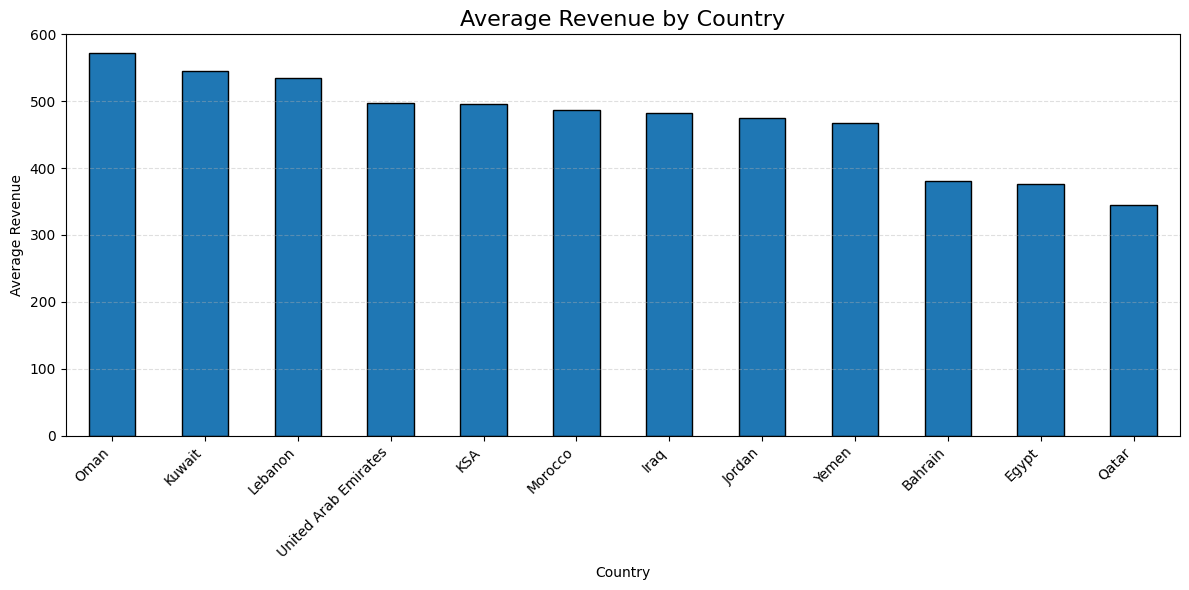

In [33]:
# Average Revenue by Country

plt.figure(figsize=(12,6))

country_revenue.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Average Revenue by Country", fontsize=16)
plt.xlabel("Country")
plt.ylabel("Average Revenue")

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

# Save chart
plt.savefig(
    "charts/bivariate/average_revenue_by_country.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Interpretation

The chart compares the average revenue generated across different countries.

Oman records the highest average revenue, followed by Kuwait and Lebanon. Countries such as the United Arab Emirates, KSA, Morocco, Iraq, Jordan, and Yemen generate relatively similar average revenue, while Bahrain, Egypt, and Qatar record comparatively lower values.

Although differences exist across countries, the variation is smaller than the differences observed in the platform analysis. This suggests that campaign performance is influenced by geographical market conditions, but platform selection appears to have a stronger impact on revenue generation within this dataset.

Overall, the analysis indicates that some countries consistently generate higher revenue, highlighting opportunities for region-specific marketing strategies and budget allocation.

# 6.3 Multivariate Analysis

## Objective

At this stage, we want to look at a few important marketing metrics together instead of one at a time. This helps us understand which variables move together, which ones seem to influence each other, and whether any clear patterns are starting to appear in the data.

This is useful because the earlier analysis showed us individual trends, but now we want a broader view of campaign performance. By comparing multiple KPIs at once, we can get a better sense of what drives results and use that information later in SQL, Power BI, and the final report.

In [37]:
# Create a folder for multivariate charts if it does not already exist
import os
os.makedirs("charts/multivariate", exist_ok=True)

# Select numeric columns for correlation analysis
num_cols = [
    "spend", "impressions", "reach", "frequency", "clicks",
    "conversions", "revenue", "video_views", "CTR", "CPC",
    "CPM", "CPA", "ROAS"
]

corr_matrix = df[num_cols].corr()
corr_matrix

,spend,impressions,reach,frequency,clicks,conversions,revenue,video_views,CTR,CPC,CPM,CPA,ROAS
spend,1.000000,0.713132,0.691926,-0.006117,0.648939,0.219771,0.187641,0.404474,0.050364,0.052455,0.073104,0.554329,0.012465
impressions,0.713132,1.000000,0.967899,-0.004708,0.577129,0.126767,0.095915,0.645300,-0.111287,-0.208325,-0.323345,0.480000,-0.022938
reach,0.691926,0.967899,1.000000,-0.144466,0.547586,0.097283,0.071220,0.625717,-0.112313,-0.198670,-0.312154,0.488911,-0.037547
frequency,-0.006117,-0.004708,-0.144466,1.000000,0.023920,0.093741,0.082399,-0.010526,0.028498,-0.027677,-0.003468,-0.056455,0.118025
clicks,0.648939,0.577129,0.547586,0.023920,1.000000,0.552776,0.483492,0.275789,0.438228,-0.261675,-0.131293,0.286337,0.265039
conversions,0.219771,0.126767,0.097283,0.093741,0.552776,1.000000,0.757420,-0.009780,0.349100,-0.109632,-0.010191,-0.068515,0.496505
revenue,0.187641,0.095915,0.071220,0.082399,0.483492,0.757420,1.000000,-0.020760,0.324369,-0.094619,-0.001092,-0.065243,0.689689
video_views,0.404474,0.645300,0.625717,-0.010526,0.275789,-0.009780,-0.020760,1.000000,-0.141228,-0.132294,-0.235981,0.328870,-0.065523
CTR,0.050364,-0.111287,-0.112313,0.028498,0.438228,0.349100,0.324369,-0.141228,1.000000,-0.333835,0.114733,-0.012756,0.478478
CPC,0.052455,-0.208325,-0.198670,-0.027677,-0.261675,-0.109632,-0.094619,-0.132294,-0.333835,1.000000,0.802530,-0.081336,-0.153857


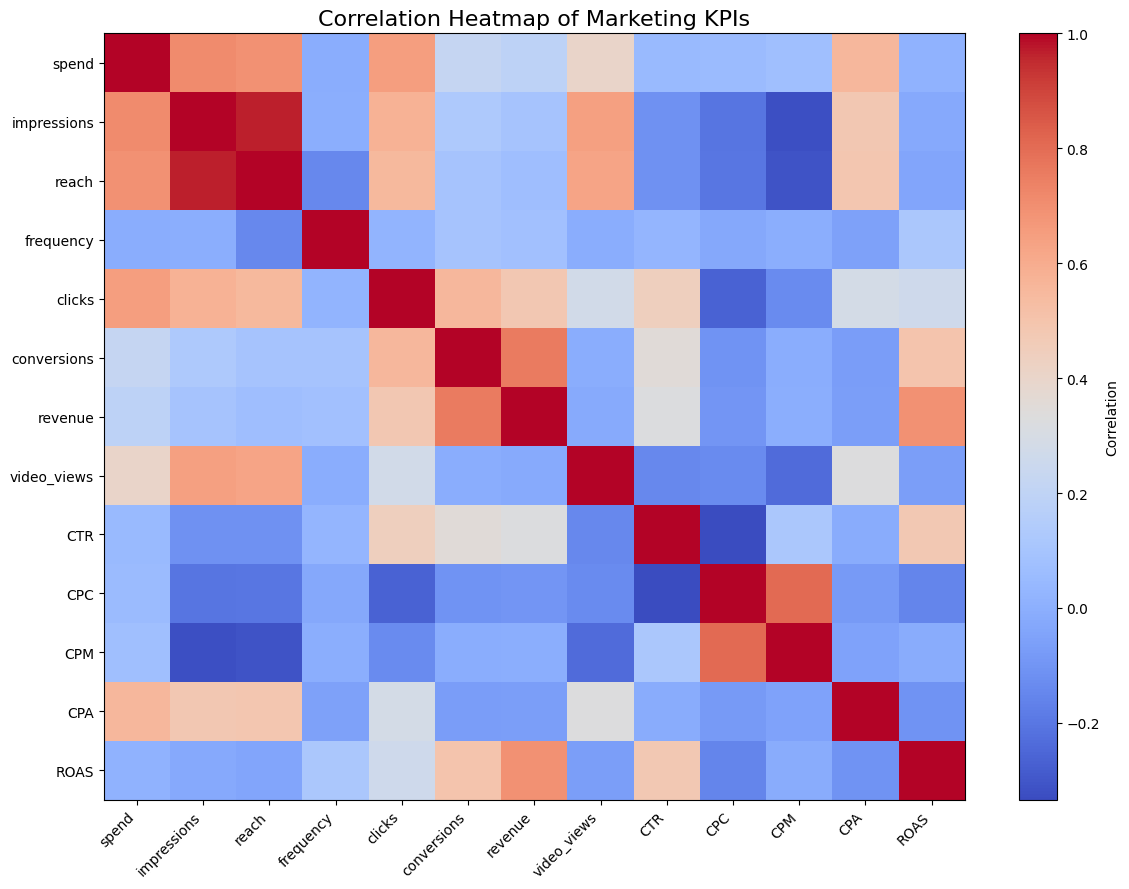

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 9))

plt.imshow(corr_matrix, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha="right")
plt.yticks(range(len(num_cols)), num_cols)

plt.title("Correlation Heatmap of Marketing KPIs", fontsize=16)
plt.tight_layout()

plt.savefig(
    "charts/multivariate/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Interpretation

The correlation heatmap shows how the key marketing KPIs move together.

A few clear patterns stand out. Impressions and reach have the strongest positive relationship, which makes sense because campaigns that are shown more often usually reach more people. Spend also shows a moderate positive relationship with clicks, impressions, and reach, suggesting that higher budgets generally help campaigns gain more visibility and interaction.

Revenue has its strongest positive relationship with conversions, which indicates that campaigns generating more conversions are also the ones producing more revenue. CTR also shows a positive relationship with clicks and conversions, which suggests that better engagement can support stronger campaign outcomes.

On the other hand, CTR has a negative relationship with CPC, which is expected because campaigns with stronger click efficiency usually cost less per click. CPC and CPM are strongly positively related, meaning campaigns with higher cost per click also tend to have higher cost per thousand impressions.

Overall, the heatmap shows that the funnel metrics behave in a logical way and confirms that the dataset has meaningful relationships between spending, engagement, conversions, and revenue.

# 7. Conclusion

## Project Summary

In this project, a digital marketing campaign dataset was analyzed to understand campaign performance across multiple business dimensions.

The analysis began with data inspection and cleaning to ensure data quality. New marketing KPIs, including CTR, CPC, CPM, CPA, and ROAS, were then calculated through feature engineering to provide additional performance indicators.

Exploratory Data Analysis was performed using univariate, bivariate, and multivariate techniques to identify trends, compare campaign performance, and examine relationships between key marketing metrics.

The analysis revealed several important findings:

- Google Search consistently delivered the strongest overall performance in terms of revenue, CTR, and ROAS.
- Sales campaigns generated the highest average revenue, while lead generation campaigns ranked second.
- Revenue increased significantly during the final quarter of the year, with November recording the highest average revenue.
- Oman, Kuwait, and Lebanon generated the highest average revenue among the countries included in the dataset.
- The correlation analysis showed meaningful relationships between spend, clicks, conversions, revenue, and other marketing KPIs, confirming that the dataset follows expected marketing performance patterns.

The cleaned dataset, engineered features, and exported visualizations created in this notebook will be used in the next stages of the project to perform SQL-based business analysis, build an interactive Power BI dashboard, and develop a Streamlit application for presenting the final insights.

In [39]:
df.to_csv(
    "digital_marketing_cleaned.csv",
    index=False
)

In [40]:
from google.colab import files

files.download("digital_marketing_cleaned.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
import shutil

shutil.make_archive(
    "charts",
    "zip",
    "charts"
)

'/content/charts.zip'